In [14]:
import pandas as pd

In [15]:
        messages = pd.read_csv('SMSSpamCollection.txt', sep='\t', names=['label', 'message'])
        messages

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [16]:
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

In [17]:
def cleaning(message):
    m = re.sub('[^a-zA-Z]', ' ', message)
    m = m.lower()
    m = m.split()
    m = [ps.stem(word) for word in m if not word in stopwords.words('english')]
    m = ' '.join(m)
    return m

In [18]:
messages['message_cleaning'] = messages['message'].apply(cleaning)
messages.head()

,label,message,message_cleaning
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [19]:
X = messages['message_cleaning'].values
X

array(['go jurong point crazi avail bugi n great world la e buffet cine got amor wat',
       'ok lar joke wif u oni',
       'free entri wkli comp win fa cup final tkt st may text fa receiv entri question std txt rate c appli',
       ..., 'piti mood suggest',
       'guy bitch act like interest buy someth els next week gave us free',
       'rofl true name'], shape=(5572,), dtype=object)

In [20]:
y = pd.get_dummies(messages['label'])
y

,ham,spam
0,True,False
1,True,False
2,False,True
3,True,False
4,True,False
...,...,...
5567,False,True
5568,True,False
5569,True,False
5570,True,False


In [21]:
y = y.iloc[:, 0].values
y

array([ True,  True, False, ...,  True,  True,  True], shape=(5572,))

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(min_df = 10, ngram_range=(1, 2))


In [24]:
X_train = tfidf.fit_transform(X_train)
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 27372 stored elements and shape (4457, 822)>

In [25]:
X_test = tfidf.transform(X_test)

In [26]:
from sklearn.svm import LinearSVC

svc = LinearSVC()
svc.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [27]:
y_pred = svc.predict(X_test)
y_pred

array([ True,  True,  True, ...,  True,  True,  True], shape=(1115,))

In [28]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.9910313901345291

In [29]:
y_pred_train = svc.predict(X_train)
accuracy_score(y_train, y_pred_train)

0.994166479694862

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[140   9]
 [  1 965]]


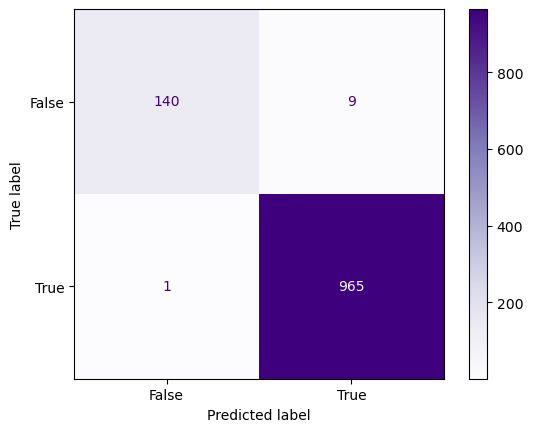

In [32]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
    display_labels=svc.classes_)

disp.plot(cmap="Purples")
plt.show()

In [33]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.99      0.94      0.97       149
        True       0.99      1.00      0.99       966

    accuracy                           0.99      1115
   macro avg       0.99      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115

